In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
# lets see if theres any correllation between rainfall and water Level
weather_df = pd.read_csv("valid_data/weather.csv")
hydro_df = pd.read_csv("valid_data/hydrometric.csv")

In [98]:
print(weather_df.head())
print(len(weather_df))

         Date      Station Name   Latitude   Longitude  MIN_TEMPERATURE  \
0  2013-01-01  CAMPBELL RIVER A  49.951944 -125.273056              1.2   
1  2013-01-02  CAMPBELL RIVER A  49.951944 -125.273056              0.0   
2  2013-01-03  CAMPBELL RIVER A  49.951944 -125.273056              0.8   
3  2013-01-04  CAMPBELL RIVER A  49.951944 -125.273056              1.3   
4  2013-01-05  CAMPBELL RIVER A  49.951944 -125.273056              1.3   

   MAX_TEMPERATURE  MEAN_TEMPERATURE  TOTAL_PRECIPITATION  TOTAL_RAIN  \
0              3.1               2.2                  0.0         0.0   
1              3.4               1.7                  0.0         0.0   
2              2.7               1.8                  1.6         1.6   
3              5.2               3.3                  6.8         6.8   
4              5.8               3.6                  7.4         7.4   

   TOTAL_SNOW  SNOW_ON_GROUND  match key  
0         0.0             3.0          1  
1         0.0           

In [99]:
# discrepency is length is okay since the same weather station is associated with two different hydrometric stations
print(hydro_df.head())
print(len(hydro_df))

         Date Station ID                  Station Name  Latitude  Longitude  \
0  2013-01-01    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
1  2013-01-02    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
2  2013-01-03    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
3  2013-01-04    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
4  2013-01-05    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   

   Daily Discharge  Daily Water Level  match key  
0             23.2             20.153          2  
1             21.3             20.126          2  
2             20.9             20.120          2  
3             21.0             20.122          2  
4             21.8             20.133          2  
20085


In [100]:
# get the subset we're interested in doing analysis on (in this case total rain and water level)
rain_data = weather_df[["Date","TOTAL_RAIN","MEAN_TEMPERATURE","TOTAL_SNOW","SNOW_ON_GROUND","match key"]]
level_data = hydro_df[["Date","Daily Discharge","Daily Water Level","match key"]]

In [101]:
# get the data for a single matched station
rain_data_0 = rain_data[rain_data["match key"] == 0]
level_data_0 = level_data[level_data["match key"] == 0]

In [102]:
rain_data_0["Date"]

8034     2013-01-01
8035     2013-01-02
8036     2013-01-03
8037     2013-01-04
8038     2013-01-05
            ...    
12046    2023-12-27
12047    2023-12-28
12048    2023-12-29
12049    2023-12-30
12050    2023-12-31
Name: Date, Length: 4017, dtype: object

In [103]:
level_data_0["Date"]

16068    2013-01-01
16069    2013-01-02
16070    2013-01-03
16071    2013-01-04
16072    2013-01-05
            ...    
20080    2023-12-27
20081    2023-12-28
20082    2023-12-29
20083    2023-12-30
20084    2023-12-31
Name: Date, Length: 4017, dtype: object

In [104]:
combine0 = rain_data_0.merge(level_data_0, on="Date")

In [105]:
combine0

,Date,TOTAL_RAIN,MEAN_TEMPERATURE,TOTAL_SNOW,SNOW_ON_GROUND,match key_x,Daily Discharge,Daily Water Level,match key_y
0,2013-01-01,0.0,-1.5,0.0,11.0,0,277.0,2.549,0
1,2013-01-02,0.0,-1.8,0.0,11.0,0,275.0,2.542,0
2,2013-01-03,0.0,-3.5,2.0,11.0,0,273.0,2.535,0
3,2013-01-04,0.0,-3.5,2.5,13.0,0,276.0,2.546,0
4,2013-01-05,0.0,-4.8,9.0,15.0,0,280.0,2.559,0
...,...,...,...,...,...,...,...,...,...
4012,2023-12-27,0.0,-1.0,0.0,4.0,0,160.0,2.201,0
4013,2023-12-28,1.0,-0.8,0.0,4.0,0,161.0,2.205,0
4014,2023-12-29,0.0,-1.0,0.0,4.0,0,160.0,2.204,0
4015,2023-12-30,0.0,-0.5,0.0,3.0,0,160.0,2.201,0


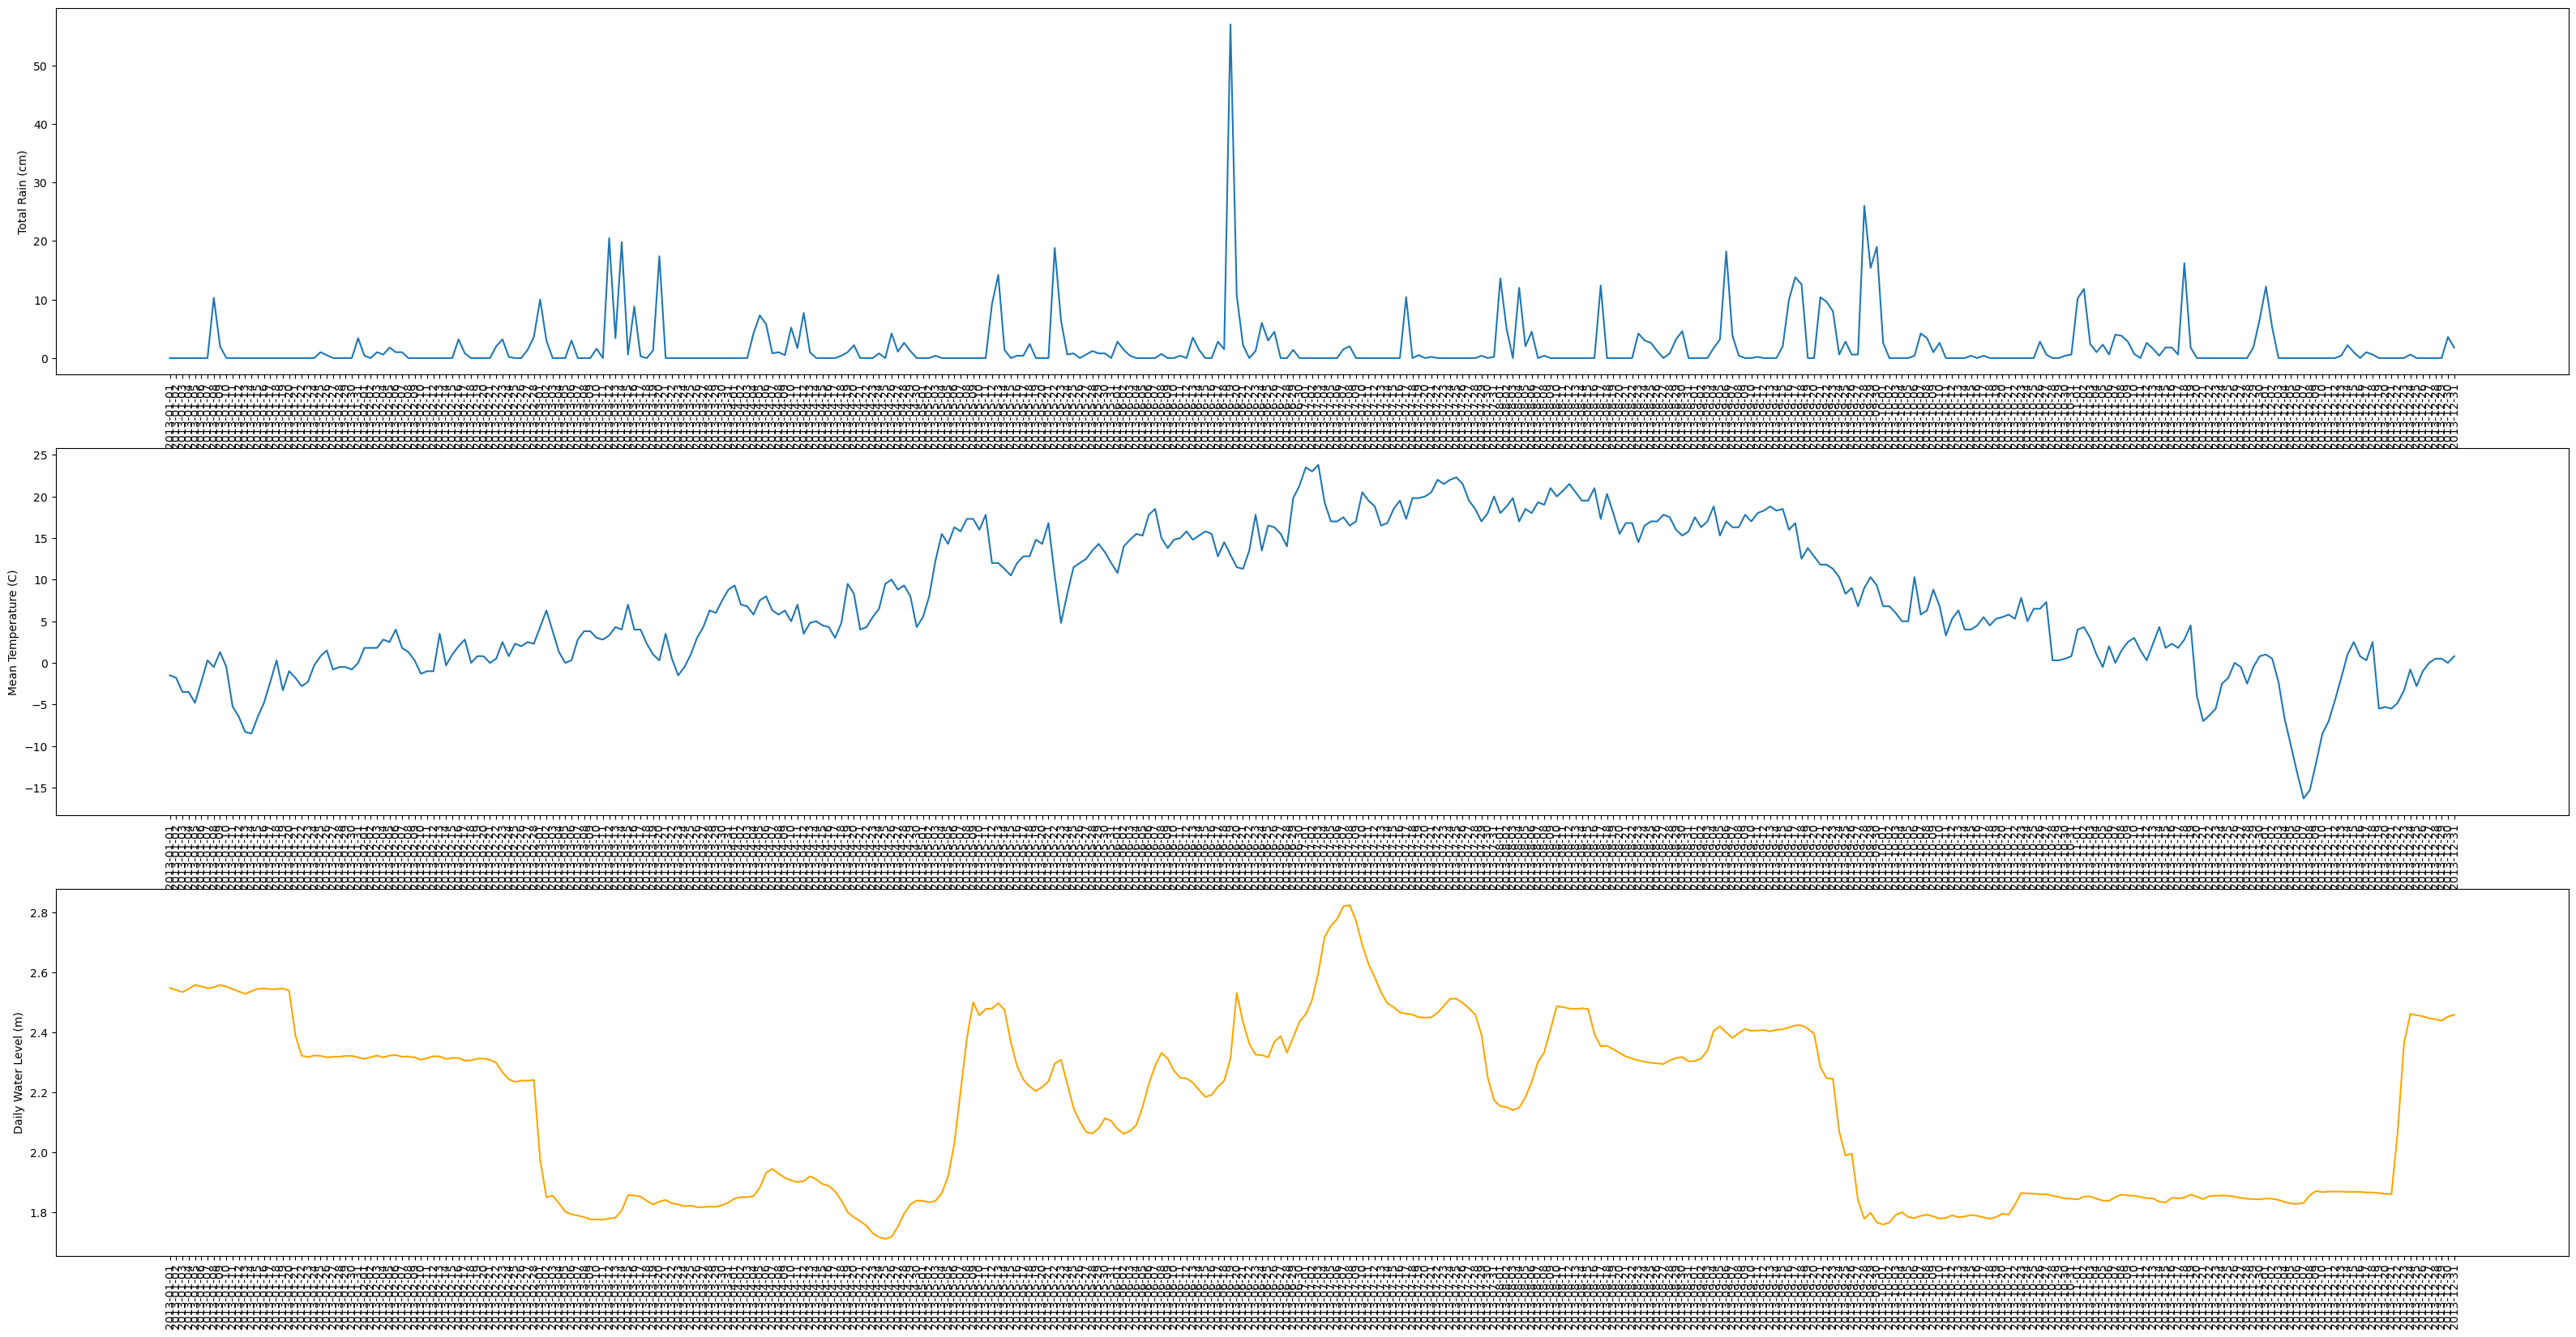

In [118]:
fig, axs = plt.subplots(3, figsize=(40,20))
x = 365
axs[0].plot(combine0["Date"][:x], combine0["TOTAL_RAIN"][:x])
axs[0].tick_params('x', labelrotation=90)
axs[0].set_ylabel("Total Rain (cm)")
axs[1].plot(combine0["Date"][:x], combine0["MEAN_TEMPERATURE"][:x])
axs[1].tick_params('x', labelrotation=90)
axs[1].set_ylabel("Mean Temperature (C)")
axs[2].plot(combine0["Date"][:x], combine0["Daily Water Level"][:x], color="orange")
axs[2].tick_params('x', labelrotation=90)
axs[2].set_ylabel("Daily Water Level (m)")
plt.show()

In [122]:
ml_data = combine0[["Date","TOTAL_RAIN","TOTAL_SNOW","MEAN_TEMPERATURE","SNOW_ON_GROUND","Daily Discharge","Daily Water Level"]]

In [123]:
ml_data["y"] = ml_data["Daily Water Level"].shift(-1)

C:\Users\Chris\AppData\Local\Temp\ipykernel_19532\3387291769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data["y"] = ml_data["Daily Water Level"].shift(-1)


In [124]:
ml_data

,Date,TOTAL_RAIN,TOTAL_SNOW,MEAN_TEMPERATURE,SNOW_ON_GROUND,Daily Discharge,Daily Water Level,y
0,2013-01-01,0.0,0.0,-1.5,11.0,277.0,2.549,2.542
1,2013-01-02,0.0,0.0,-1.8,11.0,275.0,2.542,2.535
2,2013-01-03,0.0,2.0,-3.5,11.0,273.0,2.535,2.546
3,2013-01-04,0.0,2.5,-3.5,13.0,276.0,2.546,2.559
4,2013-01-05,0.0,9.0,-4.8,15.0,280.0,2.559,2.554
...,...,...,...,...,...,...,...,...
4012,2023-12-27,0.0,0.0,-1.0,4.0,160.0,2.201,2.205
4013,2023-12-28,1.0,0.0,-0.8,4.0,161.0,2.205,2.204
4014,2023-12-29,0.0,0.0,-1.0,4.0,160.0,2.204,2.201
4015,2023-12-30,0.0,0.0,-0.5,3.0,160.0,2.201,2.196


In [125]:
ml_data = ml_data.iloc[:-1]

In [126]:
ml_data

,Date,TOTAL_RAIN,TOTAL_SNOW,MEAN_TEMPERATURE,SNOW_ON_GROUND,Daily Discharge,Daily Water Level,y
0,2013-01-01,0.0,0.0,-1.5,11.0,277.0,2.549,2.542
1,2013-01-02,0.0,0.0,-1.8,11.0,275.0,2.542,2.535
2,2013-01-03,0.0,2.0,-3.5,11.0,273.0,2.535,2.546
3,2013-01-04,0.0,2.5,-3.5,13.0,276.0,2.546,2.559
4,2013-01-05,0.0,9.0,-4.8,15.0,280.0,2.559,2.554
...,...,...,...,...,...,...,...,...
4011,2023-12-26,0.0,1.0,-2.0,4.0,160.0,2.204,2.201
4012,2023-12-27,0.0,0.0,-1.0,4.0,160.0,2.201,2.205
4013,2023-12-28,1.0,0.0,-0.8,4.0,161.0,2.205,2.204
4014,2023-12-29,0.0,0.0,-1.0,4.0,160.0,2.204,2.201


In [195]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

In [187]:
# # model
# model = make_pipeline(
#     StandardScaler(),
#     MLPRegressor(solver='lbfgs', hidden_layer_sizes=(12,8), activation='logistic', max_iter=1000000, verbose=True)
# )

X = ml_data[["TOTAL_RAIN","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
y = ml_data["y"]


# model.fit(X_train, y_train)
# print(model.score(X_valid, y_valid))

In [ ]:
scale = StandardScaler()

array([[-0.4352917 , -1.04874023,  1.5647596 ,  0.11389118],
       [-0.4352917 , -1.08351744,  1.53705228,  0.11143511],
       [-0.4352917 , -1.28058832,  1.50934495,  0.10897904],
       ...,
       [-0.17320302, -0.9675934 , -0.0422654 , -0.00680714],
       [-0.4352917 , -0.99077821, -0.05611907, -0.00715801],
       [-0.4352917 , -0.93281619, -0.05611907, -0.00821061]])

In [179]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3)


In [188]:
X

,TOTAL_RAIN,MEAN_TEMPERATURE,Daily Discharge,Daily Water Level
0,0.0,-1.5,277.0,2.549
1,0.0,-1.8,275.0,2.542
2,0.0,-3.5,273.0,2.535
3,0.0,-3.5,276.0,2.546
4,0.0,-4.8,280.0,2.559
...,...,...,...,...
4011,0.0,-2.0,160.0,2.204
4012,0.0,-1.0,160.0,2.201
4013,1.0,-0.8,161.0,2.205
4014,0.0,-1.0,160.0,2.204


In [189]:
pca = PCA(2)
pca.fit(X)

PCA(n_components=2)

In [184]:
print(pca.components_)
print(pca.explained_variance_ratio_)

[[-0.00203339  0.02667578  0.99963737  0.00306448]
 [-0.02353329 -0.99935504  0.02660418  0.00528332]]
[0.98240899 0.01333708]


In [190]:
X_pca = pca.transform(scale.fit_transform(X))

c:\Users\Chris\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [193]:
X = ml_data[["TOTAL_RAIN","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
y = ml_data["y"]

ml_data = ml_data.iloc[:-1]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3)

model = make_pipeline(
    StandardScaler(),
    PCA(3),
    MLPRegressor(hidden_layer_sizes=(8, 4), activation='logistic', solver='lbfgs', max_iter=10000)
)
model.fit(X_train, y_train)
print(model.score(X_valid, y_valid))

0.5043048041198215


In [194]:
print(model.score(X_train, y_train))

0.5118895460275328


## This seems to do decent!

In [228]:
X = ml_data[["TOTAL_RAIN","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
y = ml_data["y"]

ml_data = ml_data.iloc[:-1]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3)

model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=5)
)
model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_valid, y_valid))

0.5662769775001255
0.3252041397256755
